In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Setup

In [13]:
def show_image(image, figsize=(12, 8), dpi=100):
    plt.figure(figsize=figsize, dpi=dpi)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [14]:
def filter_lines_by_angle(lines, angle_thresh=15):
    if lines is None:
        return None, [], []
    horizontal = []
    vertical = []
    others = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Since both arguments to arctan2 are abs(...), they're always non-negative. That means the result is always in [0, 90] degrees: 
        angle = np.degrees(np.arctan2(abs(y2 - y1), abs(x2 - x1)))
        if angle <= angle_thresh:
            horizontal.append(line)
        elif angle >= 90 - angle_thresh:
            vertical.append(line)
        else:
            others.append(line)
    if not others:
        return np.empty((0, 1, 4), dtype=np.int32), horizontal, vertical
    return others, horizontal, vertical

In [15]:
def merge_horizontal_lines(lines, y_thresh=15, x_gap=30):
    """Merge horizontal line segments that likely belong to the same physical line.

    HoughLinesP often returns a single court line (e.g. the service line) as
    multiple short, fragmented segments. This function merges them by:

    1. Sorting all segments by their y-midpoint so that segments on the same
       horizontal band appear consecutively.
    2. Iterating through the sorted list and greedily merging each segment
       into the previous one when two conditions are met:
       - Their y-midpoints are within y_thresh pixels (same horizontal band).
       - The x-range gap between them is at most x_gap pixels (overlapping
         or nearly touching along the x-axis).
    3. When merging, the resulting segment spans the full x-range of both
       segments, and its y-coordinate is the average of the two midpoints.

    Args:
        lines: array of shape (N, 1, 4) with each row [x1, y1, x2, y2].
        y_thresh: max vertical distance (pixels) between midpoints to
            consider two segments part of the same line.
        x_gap: max horizontal gap (pixels) between the x-ranges of two
            segments. Negative values mean they must overlap by at least
            that many pixels.

    Returns:
        Merged segments as array of shape (M, 1, 4), where M <= N.
    """
    if lines is None or len(lines) == 0:
        return np.empty((0, 1, 4), dtype=np.int32)

    segments = sorted([line[0].tolist() for line in lines],
                      key=lambda s: (s[1] + s[3]) / 2)

    merged = [segments[0]]
    for s in segments[1:]:
        prev = merged[-1]
        prev_y = (prev[1] + prev[3]) / 2
        s_y = (s[1] + s[3]) / 2
        prev_x_min, prev_x_max = sorted([prev[0], prev[2]])
        s_x_min, s_x_max = sorted([s[0], s[2]])

        if abs(s_y - prev_y) <= y_thresh and s_x_min - prev_x_max <= x_gap:
            avg_y = int((prev_y + s_y) / 2)
            merged[-1] = [min(prev_x_min, s_x_min), avg_y,
                          max(prev_x_max, s_x_max), avg_y]
        else:
            merged.append(s)

    return np.array([[s] for s in merged], dtype=np.int32)


def merge_vertical_lines(lines, x_thresh=15, y_gap=30):
    """Merge vertical line segments that likely belong to the same physical line.

    Same approach as merge_horizontal_lines but rotated 90 degrees:

    1. Sorting all segments by their x-midpoint so that segments on the same
       vertical band appear consecutively.
    2. Iterating through the sorted list and greedily merging each segment
       into the previous one when two conditions are met:
       - Their x-midpoints are within x_thresh pixels (same vertical band).
       - The y-range gap between them is at most y_gap pixels (overlapping
         or nearly touching along the y-axis).
    3. When merging, the resulting segment spans the full y-range of both
       segments, and its x-coordinate is the average of the two midpoints.

    Args:
        lines: array of shape (N, 1, 4) with each row [x1, y1, x2, y2].
        x_thresh: max horizontal distance (pixels) between midpoints to
            consider two segments part of the same line.
        y_gap: max vertical gap (pixels) between the y-ranges of two
            segments. Negative values mean they must overlap by at least
            that many pixels.

    Returns:
        Merged segments as array of shape (M, 1, 4), where M <= N.
    """
    if lines is None or len(lines) == 0:
        return np.empty((0, 1, 4), dtype=np.int32)

    segments = sorted([line[0].tolist() for line in lines],
                      key=lambda s: (s[0] + s[2]) / 2)

    merged = [segments[0]]
    for s in segments[1:]:
        prev = merged[-1]
        prev_x = (prev[0] + prev[2]) / 2
        s_x = (s[0] + s[2]) / 2
        prev_y_min, prev_y_max = sorted([prev[1], prev[3]])
        s_y_min, s_y_max = sorted([s[1], s[3]])

        if abs(s_x - prev_x) <= x_thresh and s_y_min - prev_y_max <= y_gap:
            avg_x = int((prev_x + s_x) / 2)
            merged[-1] = [avg_x, min(prev_y_min, s_y_min),
                          avg_x, max(prev_y_max, s_y_max)]
        else:
            merged.append(s)

    return np.array([[s] for s in merged], dtype=np.int32)

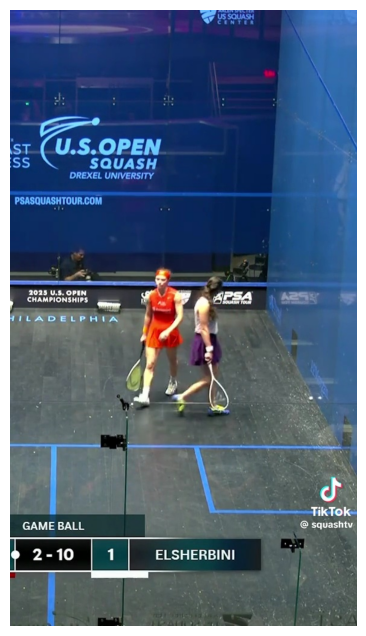

In [16]:
image = cv2.imread("../data/samples/frame_000216.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

show_image(image_rgb)

## Preprocessing

In [17]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# GaussianBlur to reduce noise and help edge detection
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

edges = cv2.Canny(blurred, 50, 150)

In [18]:

# Morphological closing (dilate -> erode) to bridge gaps in edge segments
kernel = np.ones((5, 5), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)
eroded = cv2.erode(dilated, kernel, iterations=1)

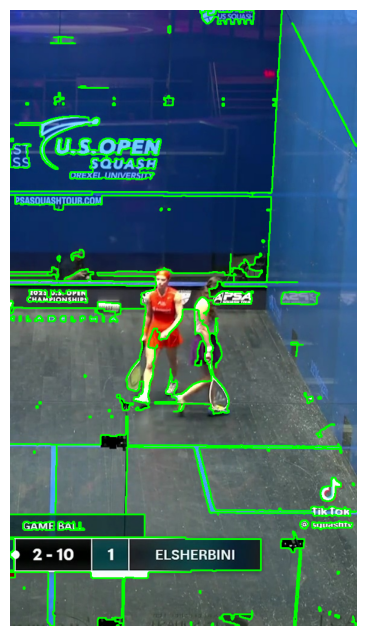

In [19]:
# Find contours in the eroded image
contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
vis = image_rgb.copy()
vis = cv2.drawContours(vis, contours, -1, (0, 255, 0), 2)  # green, thickness 2
show_image(vis)

## Line Detection (Hough Transform)

In [20]:
# Create a blank image to draw the lines
line_image = np.zeros_like(image_rgb)

In [21]:
# Use Hough Line Transform to detect lines
lines = cv2.HoughLinesP(eroded, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=10)

In [26]:
filtered_out_lines, horizontal_lines, vertical_lines = filter_lines_by_angle(lines, angle_thresh=10)

print(f"Total: {len(lines)}, Filtered: {len(filtered_out_lines)} (H: {len(horizontal_lines)}, V: {len(vertical_lines)})")


Total: 249, Filtered: 50 (H: 174, V: 25)


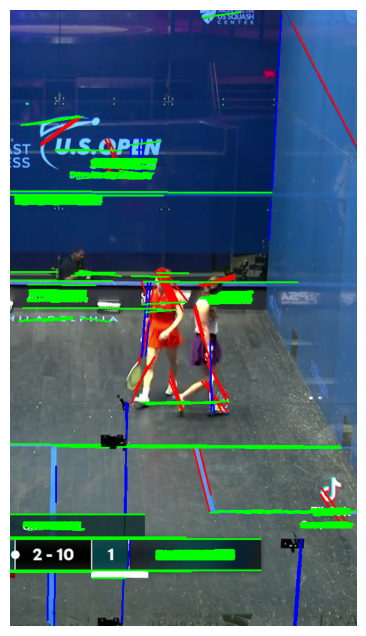

In [27]:
color_vis = image_rgb.copy()
for line in filtered_out_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(color_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)  # red = filtered_out
for line in vertical_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(color_vis, (x1, y1), (x2, y2), (0, 0, 255), 2)  # blue = vertical
for line in horizontal_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(color_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)  # green = horizontal
show_image(color_vis)

### merging lines

In [28]:
merged_h = merge_horizontal_lines(np.array(horizontal_lines))
merged_v = merge_vertical_lines(np.array(vertical_lines))

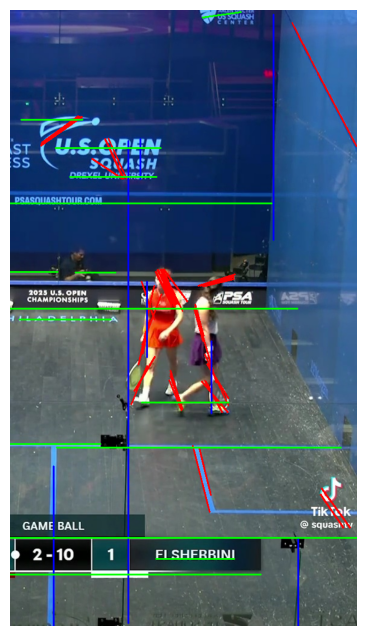

In [29]:
color_vis = image_rgb.copy()
for line in filtered_out_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(color_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)  # red = filtered_out
for line in merged_v:
    x1, y1, x2, y2 = line[0]
    cv2.line(color_vis, (x1, y1), (x2, y2), (0, 0, 255), 2)  # blue = vertical
for line in merged_h:
    x1, y1, x2, y2 = line[0]
    cv2.line(color_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)  # green = horizontal
show_image(color_vis)